<h1> Preparación y Priorización </h1>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

print(hypotheses[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False))
print(hypotheses[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000
                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2


<h1> Preprocesamiento de Datos </h1>

In [25]:

orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

users_both_groups = orders.groupby('visitorId').agg({'group': 'nunique'})
duplicate_users = users_both_groups[users_both_groups['group'] > 1].index

orders = orders[~orders['visitorId'].isin(duplicate_users)]


<h1> Análisis del Test A/B </h1>

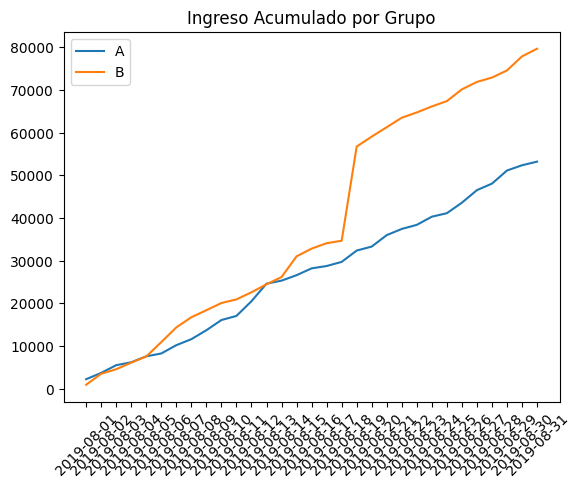

In [10]:
datesGroups = orders[['date', 'group']].drop_duplicates()

ordersAggregated = datesGroups.apply(
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]
    .agg({'date': 'max', 'group': 'max', 'transactionId': 'nunique', 'visitorId': 'nunique', 'revenue': 'sum'}),
    axis=1).sort_values(by=['date', 'group'])

plt.plot(ordersAggregated[ordersAggregated['group']=='A']['date'], ordersAggregated[ordersAggregated['group']=='A']['revenue'], label='A')
plt.plot(ordersAggregated[ordersAggregated['group']=='B']['date'], ordersAggregated[ordersAggregated['group']=='B']['revenue'], label='B')
plt.legend()
plt.title('Ingreso Acumulado por Grupo')
plt.xticks(rotation=45)
plt.show()

<h1> Análisis de Outliers </h1>

In [26]:
ordersByUsers = orders.groupby('visitorId', as_index=False).agg({'transactionId': 'nunique'})
print("Percentiles de pedidos por usuario:", np.percentile(ordersByUsers['transactionId'], [95, 99]))
print("Percentiles de ingresos:", np.percentile(orders['revenue'], [95, 99]))

normal_users = ordersByUsers[ordersByUsers['transactionId'] <= 2]['visitorId']
orders_filtered = orders[
    (orders['visitorId'].isin(normal_users)) & 
    (orders['revenue'] <= 1000)
]
print(f"Pedidos antes del filtrado: {len(orders)}")
print(f"Pedidos después del filtrado: {len(orders_filtered)}")

Percentiles de pedidos por usuario: [1. 2.]
Percentiles de ingresos: [414.275 830.3  ]
Pedidos antes del filtrado: 1016
Pedidos después del filtrado: 988


<h1> Significancia Estadística </h1>

In [18]:
sampleA = orders_filtered[orders_filtered['group'] == 'A']['revenue']
sampleB = orders_filtered[orders_filtered['group'] == 'B']['revenue']

p_value = stats.mannwhitneyu(sampleA, sampleB)[1]
print(f"P-value: {p_value:.4f}")

print(f"\nGrupo A - Media: ${sampleA.mean():.2f}, Mediana: ${sampleA.median():.2f}")
print(f"Grupo B - Media: ${sampleB.mean():.2f}, Mediana: ${sampleB.median():.2f}")

relative_diff = (sampleB.mean() - sampleA.mean()) / sampleA.mean() * 100
print(f"Diferencia relativa: {relative_diff:.2f}%")

P-value: 0.8146

Grupo A - Media: $104.74, Mediana: $50.10
Grupo B - Media: $101.11, Mediana: $45.70
Diferencia relativa: -3.46%


In [19]:
visitsAggregated = visits.groupby('group', as_index=False).agg({'visits': 'sum'})
ordersAggregated_summary = orders.groupby('group', as_index=False).agg({'transactionId': 'nunique'})

conversion_data = visitsAggregated.merge(ordersAggregated_summary, on='group')
conversion_data['conversion_rate'] = conversion_data['transactionId'] / conversion_data['visits']
print("Tasas de conversión por grupo:")
print(conversion_data)

Tasas de conversión por grupo:
  group  visits  transactionId  conversion_rate
0     A   18736            468         0.024979
1     B   18916            548         0.028970


Conclusion

Se determinó que el framework RICE es más adecuado para los objetivos estratégicos de la tienda. 
Mientras que ICE destacó hipótesis con alto impacto potencial, 
RICE priorizó aquellas que afectan a una mayor base de usuarios 
(como cambios en el checkout o en la página de inicio)